In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day,Weekday,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1,Tuesday,7,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1,Tuesday,7,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1,Tuesday,7,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1,Tuesday,7,False


In [3]:
product_sales = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    57632
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54554
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46079
ASSORTED COLOUR BIRD ORNAMENT         44805
60 TEATIME FAIRY CAKE CASES           36172
PACK OF 60 PINK PAISLEY CAKE CASES    31687
JUMBO BAG RED RETROSPOT               30668
SMALL POPCORN HOLDER                  29485
STRAWBERRY CERAMIC TRINKET BOX        26496
Name: Quantity, dtype: int64

In [4]:
inventory = product_sales.reset_index()

inventory.columns = ["Product", "UnitsSold"]

In [5]:
def recommend_stock(x):
    if x > 10000:
        return "Increase Stock"
    elif x > 3000:
        return "Maintain Stock"
    else:
        return "Reduce Stock"

inventory["Recommendation"] = inventory["UnitsSold"].apply(recommend_stock)

inventory.head(20)

,Product,UnitsSold,Recommendation
0,WHITE HANGING HEART T-LIGHT HOLDER,57632,Increase Stock
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54554,Increase Stock
2,BROCADE RING PURSE,47647,Increase Stock
3,PACK OF 72 RETRO SPOT CAKE CASES,46079,Increase Stock
4,ASSORTED COLOUR BIRD ORNAMENT,44805,Increase Stock
5,60 TEATIME FAIRY CAKE CASES,36172,Increase Stock
6,PACK OF 60 PINK PAISLEY CAKE CASES,31687,Increase Stock
7,JUMBO BAG RED RETROSPOT,30668,Increase Stock
8,SMALL POPCORN HOLDER,29485,Increase Stock
9,STRAWBERRY CERAMIC TRINKET BOX,26496,Increase Stock


In [6]:
inventory["Recommendation"].value_counts()

Recommendation
Reduce Stock      4228
Maintain Stock     366
Increase Stock      87
Name: count, dtype: int64

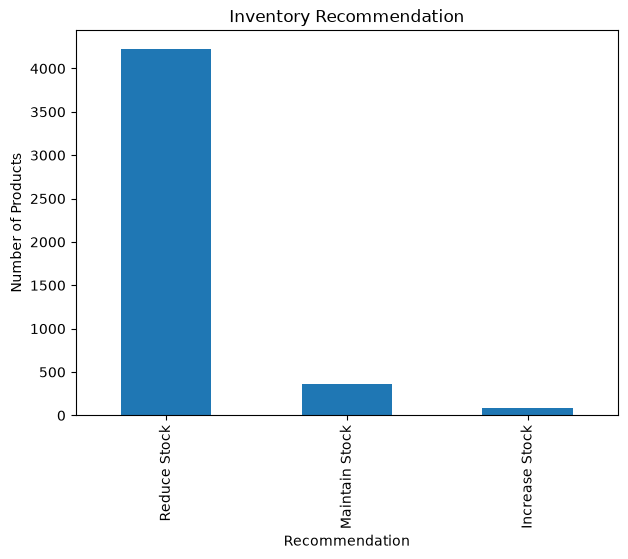

In [7]:
inventory["Recommendation"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Inventory Recommendation")
plt.ylabel("Number of Products")
plt.show()

In [8]:
inventory.to_csv(
    "../data/processed/inventory_recommendation.csv",
    index=False
)

print("Inventory Recommendation Completed!")

Inventory Recommendation Completed!
